<a href="https://colab.research.google.com/github/saranya0207/Project2_DataManagement/blob/main/movielens_report.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MovieLens 100K Dataset Analysis**

# 1. Introduction
This project analyses MovieLens 100K dataset using Apache Spark and Cassandra.

# 2. Objectives
We aim to analyse:
1. Average movie ratings for each movies.
2. Top 10 movies with the highest average ratings.
3. Users who have rated at least 50 movies and their favourite movie genre.
4. Users under 20 years old.
5. Users whose occupation is “scientist” and age is between 30 and 40 years old.

# 3. Methodology

### 3.1 Download MovieLens 100K
https://grouplens.org/datasets/movielens/100k/

Files used:
 1.   u.data
 2.   u.item
 3.   u.user

### 3.2 Upload files to cluster (PuTTY)
Load and parse the MovieLens dataset files into HDFS.
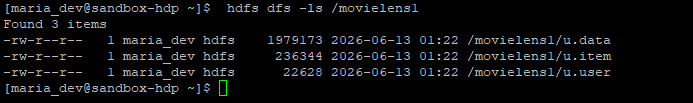

### 3.3 Create Cassandra keyspace and tables
#### 3.3.1 Open Cassandra
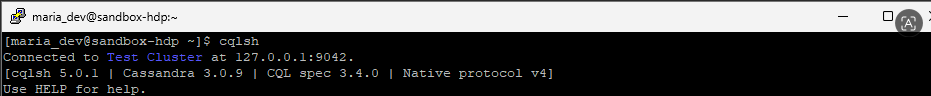
#### 3.3.2 Create Keyspace
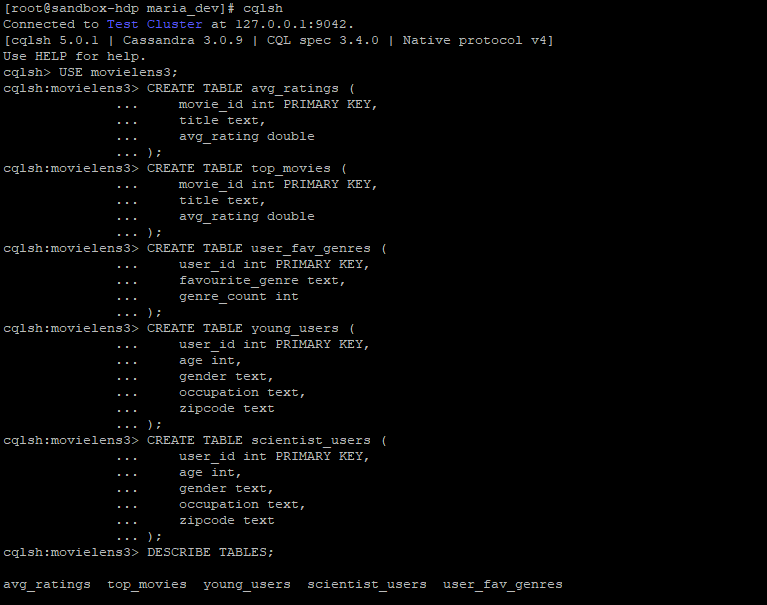

### 3.4 Create Python Spark File
In PuTTY:

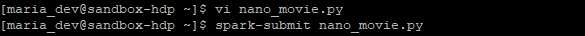

The complete Python script can be found on GitHub.

# 4.0 Results and Analysis

In [ ]:
# @title
import pandas as pd

In [ ]:
# @title
users = pd.read_csv(
    "u.user",
    sep="|",
    header=None,
    names=["user_id", "age", "gender", "occupation", "zipcode"]
)

users.head()

,user_id,age,gender,occupation,zipcode
0,1,24,M,technician,85711
1,2,53,F,other,94043
2,3,23,M,writer,32067
3,4,24,M,technician,43537
4,5,33,F,other,15213


In [ ]:
# @title
ratings = pd.read_csv(
    "u.data",
    sep="\t",
    header=None,
    names=["user_id", "movie_id", "rating", "timestamp"]
)

ratings.head()

,user_id,movie_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [ ]:
# @title
genre_cols = [
    "unknown","action","adventure","animation","children",
    "comedy","crime","documentary","drama","fantasy",
    "film_noir","horror","musical","mystery","romance",
    "sci_fi","thriller","war","western"
]

movie_cols = [
    "movie_id","title","release_date","video_release_date","IMDb_URL"
] + genre_cols


In [ ]:
# @title
movies = pd.read_csv(
    "u.item",
    sep="|",
    encoding="latin-1",
    header=None,
    names=movie_cols
)

movies.head()

,movie_id,title,release_date,video_release_date,IMDb_URL,unknown,action,adventure,animation,children,...,fantasy,film_noir,horror,musical,mystery,romance,sci_fi,thriller,war,western
0,1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


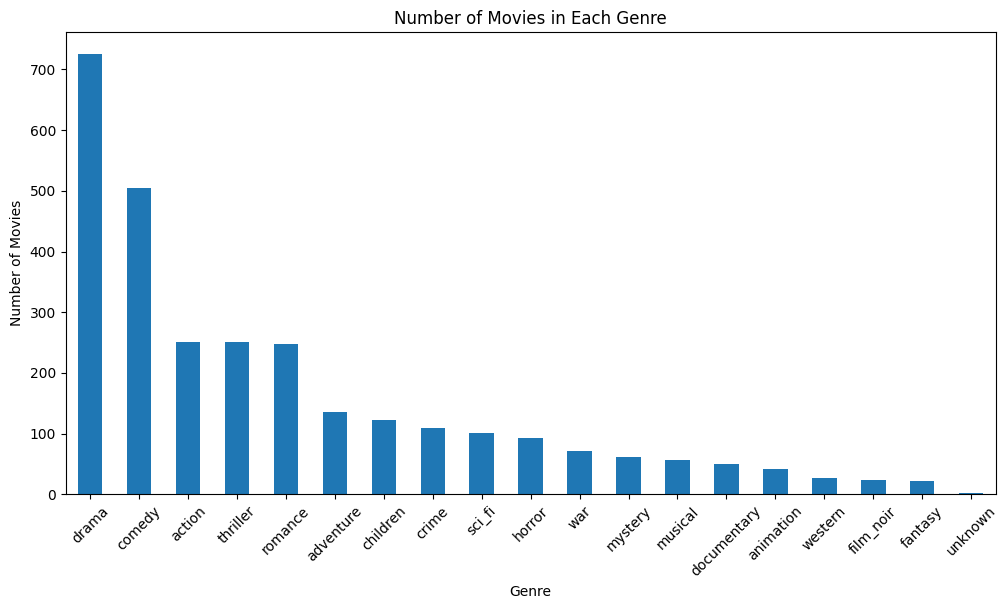

In [ ]:
# @title
# Movie Genre Distribution
genre_totals = movies[genre_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))

genre_totals.plot(kind='bar')

plt.title('Number of Movies in Each Genre')
plt.xlabel('Genre')
plt.ylabel('Number of Movies')

plt.xticks(rotation=45)

plt.show()

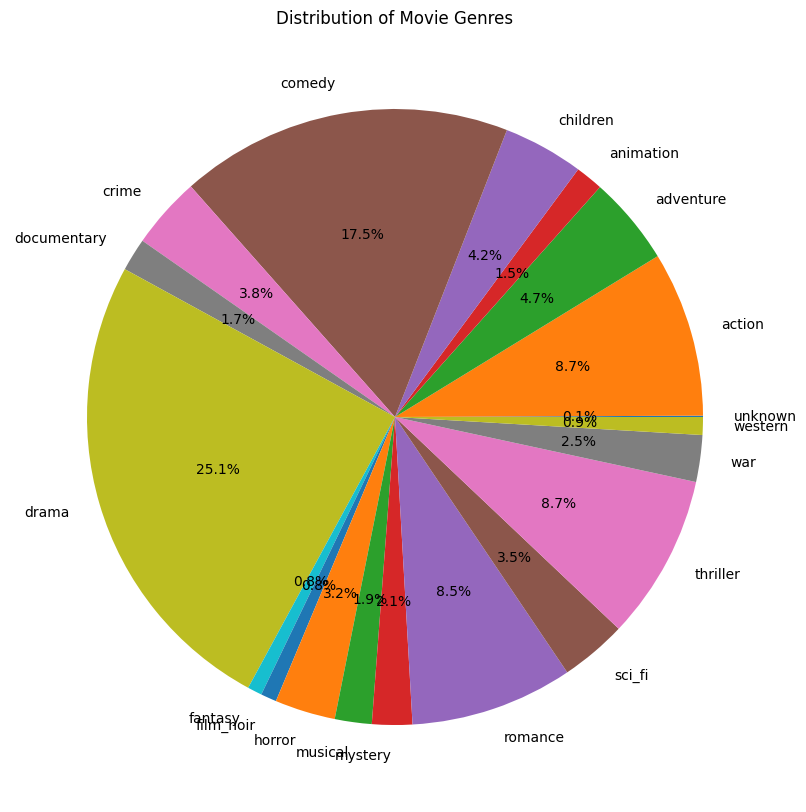

In [ ]:
# @title
genre_totals = movies[genre_cols].sum()

plt.figure(figsize=(10,10))

plt.pie(
    genre_totals,
    labels=genre_totals.index,
    autopct='%1.1f%%'
)

plt.title('Distribution of Movie Genres')

plt.show()

The bar chart and pie chart together illustrate the distribution of movies across different genres in the dataset. Both visualizations show that drama is the most dominant genre, with more than 700 movies, accounting for the largest proportion of the dataset. Comedy ranks second with over 500 movies, representing another substantial share. Action, thriller, and romance form a second tier of popular genres, each containing approximately 250 movies. Genres such as adventure, children, crime, sci-fi, and horror have moderate representation, while war, mystery, musical, documentary, and animation contribute relatively smaller shares. The least represented genres are western, film-noir, fantasy, and unknown, each accounting for only a small fraction of the total movies. Overall, both charts reveal a highly uneven genre distribution, with drama and comedy collectively comprising a significant portion of the dataset, while many other genres are comparatively underrepresented. This suggests that the movie collection is concentrated in a few popular genres rather than being evenly distributed across all categories.


# Task 1 : Calculate the average rating for each movie.

In [ ]:
# @title
# Calculate the average rating for each movie.
avg_rating = ratings.groupby("movie_id")["rating"].mean().reset_index()

avg_rating = avg_rating.merge(
    movies[["movie_id","title"]],
    on="movie_id"
)

avg_rating.rename(
    columns={"rating":"average_rating"},
    inplace=True
)

avg_rating.sort_values(
    by="average_rating",
    ascending=False
).head()

,movie_id,average_rating,title
1188,1189,5.0,Prefontaine (1997)
1499,1500,5.0,Santa with Muscles (1996)
1200,1201,5.0,Marlene Dietrich: Shadow and Light (1996)
1292,1293,5.0,Star Kid (1997)
1652,1653,5.0,Entertaining Angels: The Dorothy Day Story (1996)


Output from Cassandra:

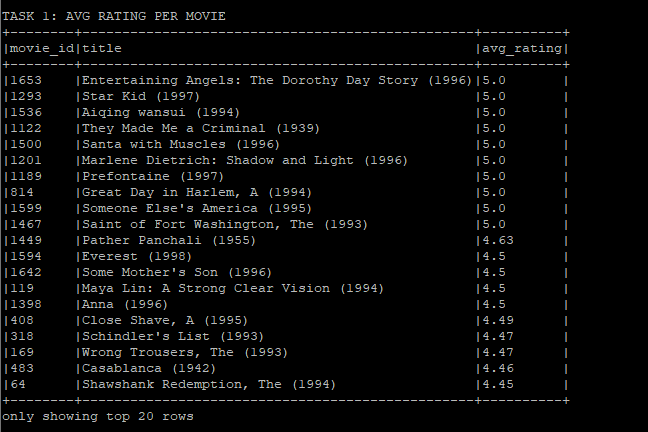

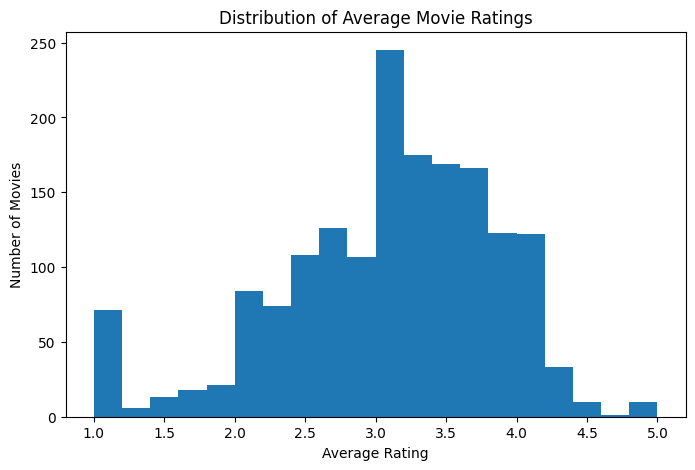

In [ ]:
# @title
# Average Rating for Each Movie
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(avg_rating['average_rating'], bins=20)
plt.title('Distribution of Average Movie Ratings')
plt.xlabel('Average Rating')
plt.ylabel('Number of Movies')
plt.show()

# Most movies have average ratings between 3 and 4.

The histogram of average movie ratings shows a negatively skewed distribution, with most movies receiving moderate to high ratings and relatively few receiving very low scores. The highest concentration of movies falls within the 3.0 to 4.2 rating range, indicating that audiences generally rate films positively. Overall, the distribution reflects a typical positivity bias in entertainment ratings, where most films are perceived as average to good, while both exceptionally poor and outstanding movies are relatively rare.

# Task 2 : Identify the top ten movies with the highest average ratings

In [ ]:
# @title
# Identify the top ten movies with the highest average ratings.
top10_movies = avg_rating.sort_values(
    by="average_rating",
    ascending=False
  ).head(10)

print(top10_movies[["movie_id","title","average_rating"]])

      movie_id                                              title  \
1188      1189                                 Prefontaine (1997)   
1499      1500                          Santa with Muscles (1996)   
1200      1201         Marlene Dietrich: Shadow and Light (1996)    
1292      1293                                    Star Kid (1997)   
1652      1653  Entertaining Angels: The Dorothy Day Story (1996)   
1121      1122                     They Made Me a Criminal (1939)   
813        814                      Great Day in Harlem, A (1994)   
1466      1467               Saint of Fort Washington, The (1993)   
1535      1536                               Aiqing wansui (1994)   
1598      1599                      Someone Else's America (1995)   

      average_rating  
1188             5.0  
1499             5.0  
1200             5.0  
1292             5.0  
1652             5.0  
1121             5.0  
813              5.0  
1466             5.0  
1535             5.0  
1598      

Output from Cassandra:

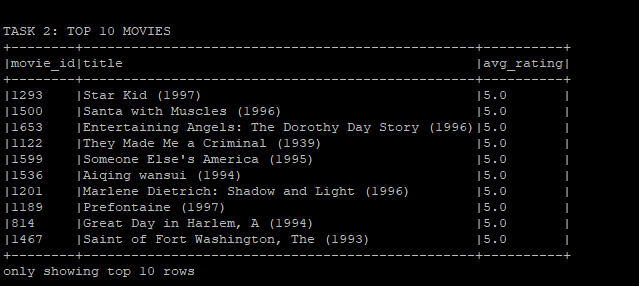

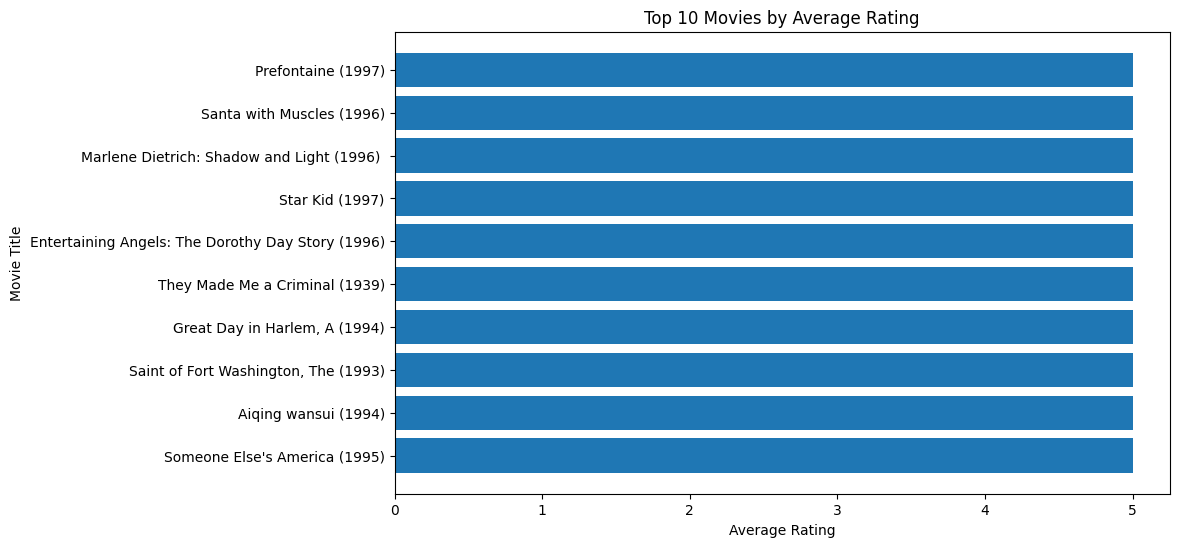

In [ ]:
# @title
# Top 10 Movies with Highest Average Ratings
plt.figure(figsize=(10,6))

plt.barh(
    top10_movies['title'],
    top10_movies['average_rating']
)

plt.xlabel('Average Rating')
plt.ylabel('Movie Title')
plt.title('Top 10 Movies by Average Rating')

plt.gca().invert_yaxis()

plt.show()

The bar chart presents the Top 10 Movies by Average Rating. All ten movies have an average rating very close to 5.0, indicating that they received extremely positive reviews from users.

# Task 3: Identify users who have rated at least 50 movies and determine their favourite movie genre based on the genre they rated most frequently.


Output from Cassandra:

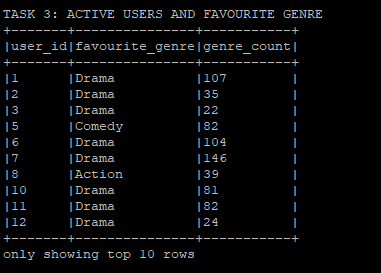

In [ ]:
# @title
# Identify users who rated at least 50 movies
user_rating_counts = ratings.groupby("user_id").size().reset_index(name="num_ratings")

active_users = user_rating_counts[
    user_rating_counts["num_ratings"] >= 50
]["user_id"]

# Ratings from active users
active_ratings = ratings[
    ratings["user_id"].isin(active_users)
]

# Merge ratings with movie genres
user_movie_genres = active_ratings.merge(
    movies[["movie_id"] + genre_cols],
    on="movie_id"
)

# Count genre frequencies for each user
genre_counts = []

for genre in genre_cols:
    temp = (
        user_movie_genres[user_movie_genres[genre] == 1]
        .groupby("user_id")
        .size()
        .reset_index(name="count")
    )
    temp["genre"] = genre
    genre_counts.append(temp)

genre_counts = pd.concat(genre_counts, ignore_index=True)

# Determine favourite genre for each user
favorite_genres = (
    genre_counts.sort_values(
        ["user_id", "count"],
        ascending=[True, False]
    )
    .groupby("user_id")
    .first()
    .reset_index()
)

# Add number of ratings
favorite_genres = favorite_genres.merge(
    user_rating_counts,
    on="user_id"
)

favorite_genres = favorite_genres[
    ["user_id", "num_ratings", "genre", "count"]
]

favorite_genres.rename(
    columns={
        "genre": "favorite_genre",
        "count": "genre_rating_count"
    },
    inplace=True
)

favorite_genres

,user_id,num_ratings,favorite_genre,genre_rating_count
0,1,272,drama,107
1,2,62,drama,35
2,3,54,drama,22
3,5,175,comedy,82
4,6,211,drama,104
...,...,...,...,...
563,936,142,drama,68
564,938,108,comedy,40
565,940,107,drama,48
566,942,79,drama,31


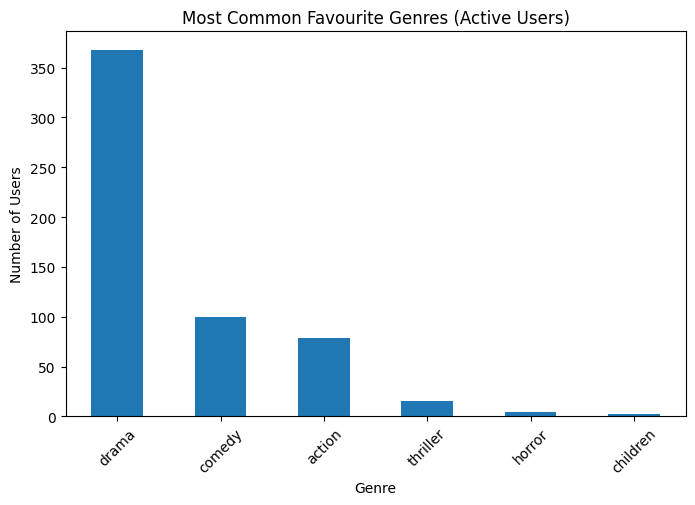

In [ ]:
# @title
plt.figure(figsize=(8,5))

favorite_genres["favorite_genre"].value_counts().plot(kind="bar")

plt.xlabel("Genre")
plt.ylabel("Number of Users")
plt.title("Most Common Favourite Genres (Active Users)")

plt.xticks(rotation=45)
plt.show()

Based on the bar chart, Drama is clearly the most dominant favourite genre among active users, with approximately 365–370 users selecting it as their top preference. This shows a strong tendency among users to prefer story-driven and emotionally engaging content. Comedy and Action follow as the next most preferred genres, with around 100 users and 80 users respectively, indicating moderate popularity compared to Drama. In contrast, genres such as Thriller, Horror, and Children are far less preferred, each accounting for only a small number of users, generally below 20. Overall, the chart highlights a clear imbalance in genre preference, with Drama being the overwhelming favourite, while other genres remain niche choices among active users.


# Task 4: Find all users who are less than 20 years old.


In [ ]:
# Find all users who are less than 20 years old.
under20 = users[
    users["age"] < 20
]

print(under20)

     user_id  age gender occupation zipcode
29        30    7      M    student   55436
35        36   19      F    student   93117
51        52   18      F    student   55105
56        57   16      M       none   84010
66        67   17      M    student   60402
..       ...  ...    ...        ...     ...
871      872   19      F    student   74078
879      880   13      M    student   83702
886      887   14      F    student   27249
903      904   17      F    student   61073
924      925   18      F   salesman   49036

[77 rows x 5 columns]


Output from Cassandra:

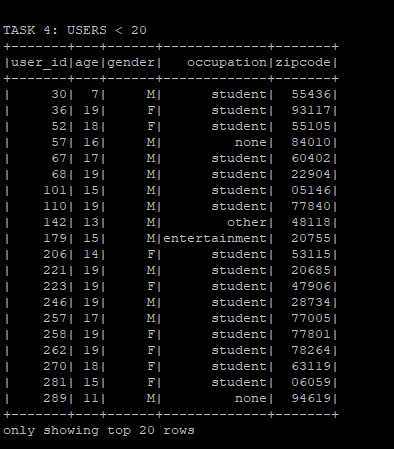


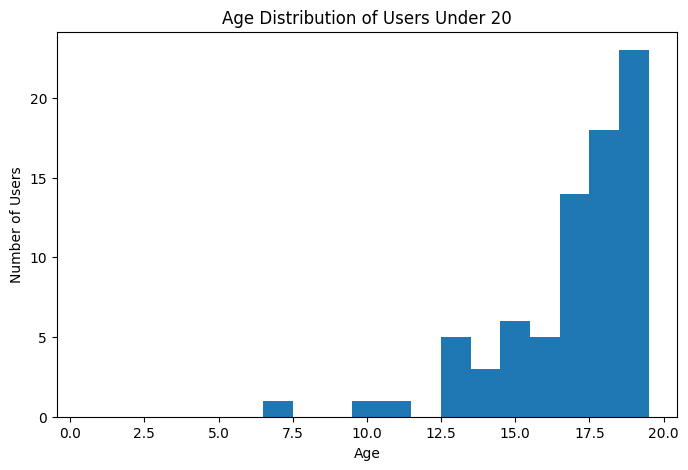

In [ ]:
# @title
# Users Less Than 20 Years Old
plt.figure(figsize=(8,5))

plt.hist(
    under20['age'],
    bins=range(1,21),
    align='left'
)

plt.title('Age Distribution of Users Under 20')
plt.xlabel('Age')
plt.ylabel('Number of Users')

plt.show()

The histogram illustrates the age distribution of users under 20 years old. The distribution is concentrated toward the upper end of the age range, with the highest frequencies occurring between 17 and 19 years old. The number of users increases steadily as age increases, reaching a peak at 19 years old, which appears to be the most common age in this group. In contrast, there are relatively few users below the age of 15, and only a handful of users are observed between 7 and 12 years old. This results in a left-skewed (negatively skewed) distribution, where the majority of observations are clustered at higher ages and a long tail extends toward the younger ages. Overall, the histogram suggests that most users classified as "under 20" are actually in their late teenage years, while younger teenagers and children make up a much smaller proportion of the user base.

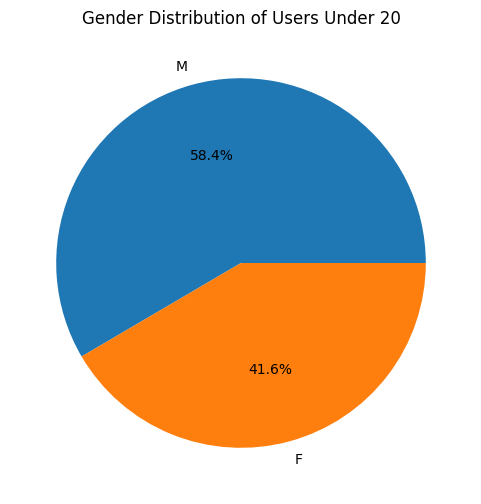

In [ ]:
# @title
#Users Under 20 by Gender
gender_counts = under20['gender'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct='%1.1f%%'
)

plt.title('Gender Distribution of Users Under 20')

plt.show()

The pie chart shows the gender distribution of users in the dataset. Male users represent the majority, accounting for 58.4% of the total user population, while female users make up the remaining 41.6%. The blue segment corresponds to male users (M), and the orange segment represents female users (F). Although males constitute the larger share, the difference between the two groups is not substantial, indicating a relatively balanced gender distribution. Overall, the dataset contains a slightly higher proportion of male users, suggesting that males are somewhat more represented in the movie rating platform than females.

# Task 5: Find all users whose occupation is “scientist” and whose age is between 30 and 40 years old.

In [ ]:
# Find all users whose occupation is “scientist” and whose age is between 30 and 40 years old.
scientists = users[
    (users["occupation"] == "scientist") &
    (users["age"] >= 30) &
    (users["age"] <= 40)
]

print(scientists)

     user_id  age gender occupation zipcode
39        40   38      M  scientist   27514
70        71   39      M  scientist   98034
73        74   39      M  scientist   T8H1N
106      107   39      M  scientist   60466
182      183   33      M  scientist   27708
271      272   33      M  scientist   53706
308      309   40      M  scientist   70802
336      337   37      M  scientist   10522
429      430   38      M  scientist   98199
537      538   31      M  scientist   21010
542      543   33      M  scientist   95123
553      554   32      M  scientist   62901
642      643   39      M  scientist   55122
729      730   31      F  scientist   32114
873      874   36      M  scientist   37076
917      918   40      M  scientist   70116


Output from Cassandra:

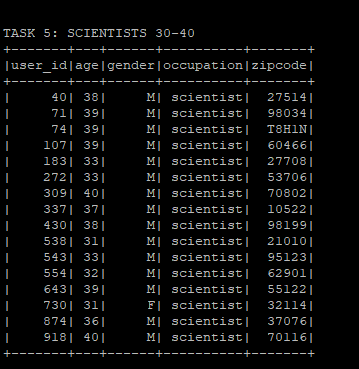

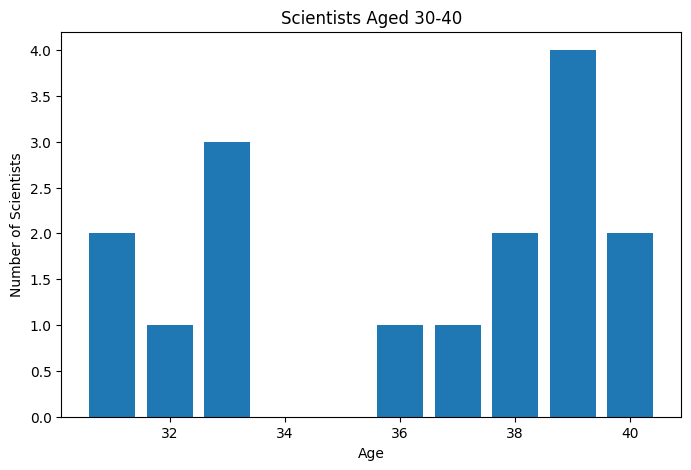

In [ ]:
# Scientists Aged 30–40
scientist_age_counts = scientists['age'].value_counts().sort_index()

plt.figure(figsize=(8,5))

plt.bar(
    scientist_age_counts.index,
    scientist_age_counts.values
)

plt.title('Scientists Aged 30-40')
plt.xlabel('Age')
plt.ylabel('Number of Scientists')

plt.show()

The histogram displays the age distribution of scientists aged between 30 and 40 years old. The ages are fairly spread across the range, with a noticeable concentration in the late thirties. The highest frequency occurs at 39 years old, making it the most common age among the scientists in this group. Ages 33, 38, and 40 also have relatively high counts, while fewer scientists are observed at ages 32, 36, and 37. Overall, the distribution suggests that scientists in this sample tend to be concentrated toward the upper end of the 30–40 age range, indicating a greater representation of individuals with more professional experience. However, the small sample size means that the distribution should be interpreted with caution, as it may not accurately represent the broader population of scientists.


# 5.0 Conclusion

This study successfully built a data pipeline using Apache Spark and Cassandra to analyse the MovieLens 100k dataset and extract meaningful insights from user ratings, movie metadata, and user demographics. The analysis showed that the average movie ratings vary across titles, allowing the identification of the top ten highest-rated movies, which represent the most positively received content in the dataset.

User behaviour analysis revealed that active users (those who rated at least 50 movies) have a strong preference for specific genres, with Drama emerging as the most frequently chosen favourite genre, followed by Comedy and Action. This highlights a clear concentration of interest in emotionally driven and mainstream genres among engaged users.

The demographic filtering further provided insights into the user base. A subset of users under 20 years old was identified, as well as users in the “scientist” occupation category aged between 30 and 40, which demonstrates the capability of the pipeline to support targeted user segmentation.

Overall, the implemented Spark–Cassandra pipeline proved effective in handling large-scale data processing and enabling both rating-based and demographic-based analysis. It demonstrates how distributed data systems can be used to efficiently process recommendation-style datasets and generate actionable insights for understanding user preferences and behaviour patterns.
